# Plot land carbon pool composition

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


/g100/home/userexternal/ekoehn00/.conda/envs/eekenv/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Set parameters

In [19]:
#stat = 'integral'#'integral'#'mean'
#freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['cLand','cSoil','cVeg','cCwd','cLitter'] # 'tas','tos',
models = ['GISSE2.1-G-CC2']#['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM','UKESM1-2','EC-Earth3-ESM-1']#[]#, ]#, # 
runs = pruns.get_run_list('tipmip_tier1')#[1:]
ref_year = 1

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()

def get_freq_input(model):
    if model == 'GISSE2.1-G-CC2':
        freq_input = 'yearly'
    else:
        freq_input = 'monthly'
    return freq_input

## Convert time series

In [20]:
def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'nbp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kgC/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units in ['mol m-2 s-1 x m2','mol/m2/s x m2']:
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units in ['kg m-2 s-1 x m2','kg/m2/s x m2']:
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'cLand' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cSoil' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cVeg' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cCwd' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    elif varia == 'cLitter' and stat == 'integral' and da.units in ['kg m-2 x m2','kg/m2 x m2']:
        converter = 1 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC'
    else:
        da_conv = da
    return da_conv

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['fgco2','intpp','nbp','npp','cLand','cSoil','cVeg','cCwd','cLitter']:
            stat = 'integral'
    else:
        stat = 'mean'
    return stat

## Load and plot individual models, yearly means (and monthly means if available)

In [21]:
def get_time_series(model,varia):
    freq_input = get_freq_input(model)
    stat = get_stat(varia)
    mgrab = MODELgrabber.get_grabber(model)
    member = mgrab.get_member()
    #color = model_dict[model].color_id
    global_stats = dict() 
    for run in runs:
        try:
            color = run_dict[run].color_id
            # get the data
            load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
            load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_global_{stat}.nc'
            global_stat = xr.open_dataset(load_string,use_cftime=True)
            global_stat = global_stat[f"{varia}_global_{stat}"]
            # convert
            global_stat = convert_units(varia,stat,global_stat)
            # put into dictionary
            global_stats[run] = global_stat
        except:
            print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
    return global_stats

In [22]:
global_stats = dict()
for model in models:
    global_stats[model] = dict()
    for varia in varias:
        global_stats[model][varia] = get_time_series(model,varia)


Nothing to plot for cLand, GISSE2.1-G-CC2, r0i0p0f0, esm-piControl, yearly, global integral.
Nothing to plot for cLand, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0, yearly, global integral.
Nothing to plot for cLand, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl2p0, yearly, global integral.
Nothing to plot for cLand, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0, yearly, global integral.
Nothing to plot for cLand, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl2p0-50y-dn2p0, yearly, global integral.
Nothing to plot for cLand, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0, yearly, global integral.
Nothing to plot for cLand, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0, yearly, global integral.
Nothing to plot for cSoil, GISSE2.1-G-CC2, r0i0p0f0, esm-piControl, yearly, global integral.
Nothing to plot for cSoil, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0, yearly, global integral.
Nothing to plot for cSoil, GISSE2.1-G-CC2, r0i0p0f0, esm-up2p0-gwl2p0, yearly, global integral.
Nothing to plot for cSo

## Plot the land carbon pool sizes

/scratch_local/slurm_job.20084157/ipykernel_9945/1024964516.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc='lower left', bbox_to_anchor=(1.01, 0.01))
/scratch_local/slurm_job.20084157/ipykernel_9945/1024964516.py:58: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend().remove()


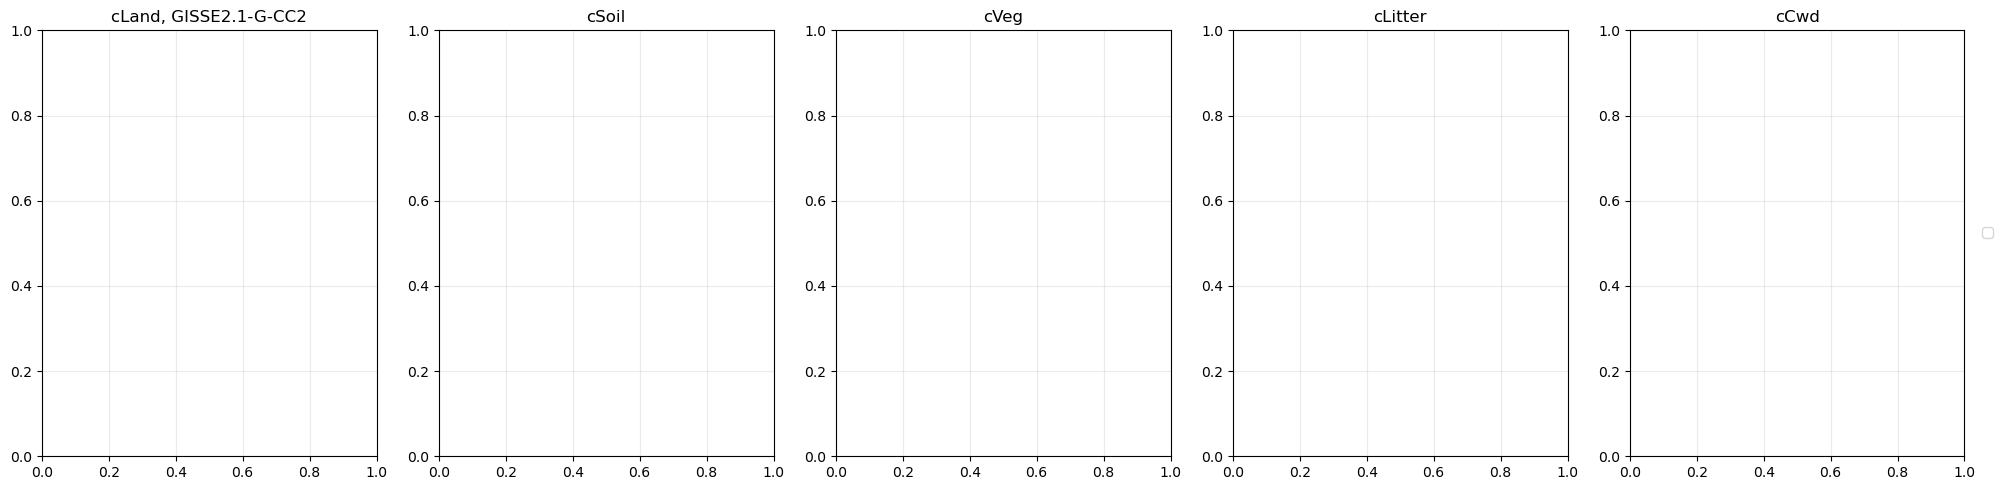

In [23]:
for model in models:
    freq_input = get_freq_input(model)
    stat = get_stat(varia)

    fig, ax = plt.subplots(1, 5, figsize=(20, 5))

    # variables mapped to axes
    var_map = [
        ('cLand', ax[0]),
        ('cSoil', ax[1]),
        ('cVeg',  ax[2]),
        ('cLitter',  ax[3]),
        ('cCwd', ax[4]),
    ]

    def plot_pair(da, axis, color, label=None):
        da.plot(alpha=0.25, color=color, ax=axis)
        da.resample(time="1YS").mean().plot(
            alpha=1, color=color, ax=axis, label=label
        )

    for run in runs:
        color = run_dict[run].color_id

        for var, axis in var_map:
            da = global_stats[model].get(var, {}).get(run, None)

            if da is None:
                continue  # skip missing variable cleanly

            try:
                # only label on first panel to avoid duplicate legends
                label = run if var == 'cLand' else None
                plot_pair(da, axis, color, label)
            except Exception as e:
                print(f"Skipping {var}, {model}, {run}: {e}")

    # --- titles ---
    titles = ['cLand', 'cSoil', 'cVeg', 'cLitter', 'cCwd']
    for axi, title in zip(ax, titles):
        axi.set_title(f'{title}, {model}' if title == 'cLand' else title)

    # --- styling ---
    for axi in ax:
        axi.grid(alpha=0.25)

    # legend
    plt.subplots_adjust(right=0.7)
    ax[0].legend(loc='lower left', bbox_to_anchor=(1.01, 0.01))

    handles, labels = ax[0].get_legend_handles_labels()
    
    fig.legend(
        handles, labels,
        loc='lower left',
        bbox_to_anchor=(0.99, 0.5)  # adjust position
    )
    ax[0].legend().remove()
    
    plt.tight_layout()
    plt.show()

## Plot the relative contributions to the total cLand pool

Skipping GISSE2.1-G-CC2, esm-piControl: 'esm-piControl'
Skipping GISSE2.1-G-CC2, esm-up2p0: 'esm-up2p0'
Skipping GISSE2.1-G-CC2, esm-up2p0-gwl2p0: 'esm-up2p0-gwl2p0'
Skipping GISSE2.1-G-CC2, esm-up2p0-gwl4p0: 'esm-up2p0-gwl4p0'
Skipping GISSE2.1-G-CC2, esm-up2p0-gwl2p0-50y-dn2p0: 'esm-up2p0-gwl2p0-50y-dn2p0'
Skipping GISSE2.1-G-CC2, esm-up2p0-gwl4p0-50y-dn2p0: 'esm-up2p0-gwl4p0-50y-dn2p0'
Skipping GISSE2.1-G-CC2, esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0: 'esm-up2p0-gwl4p0-50y-dn2p0-gwl2p0'


/scratch_local/slurm_job.20084157/ipykernel_9945/2734594976.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower left', bbox_to_anchor=(1.01, 0.01))


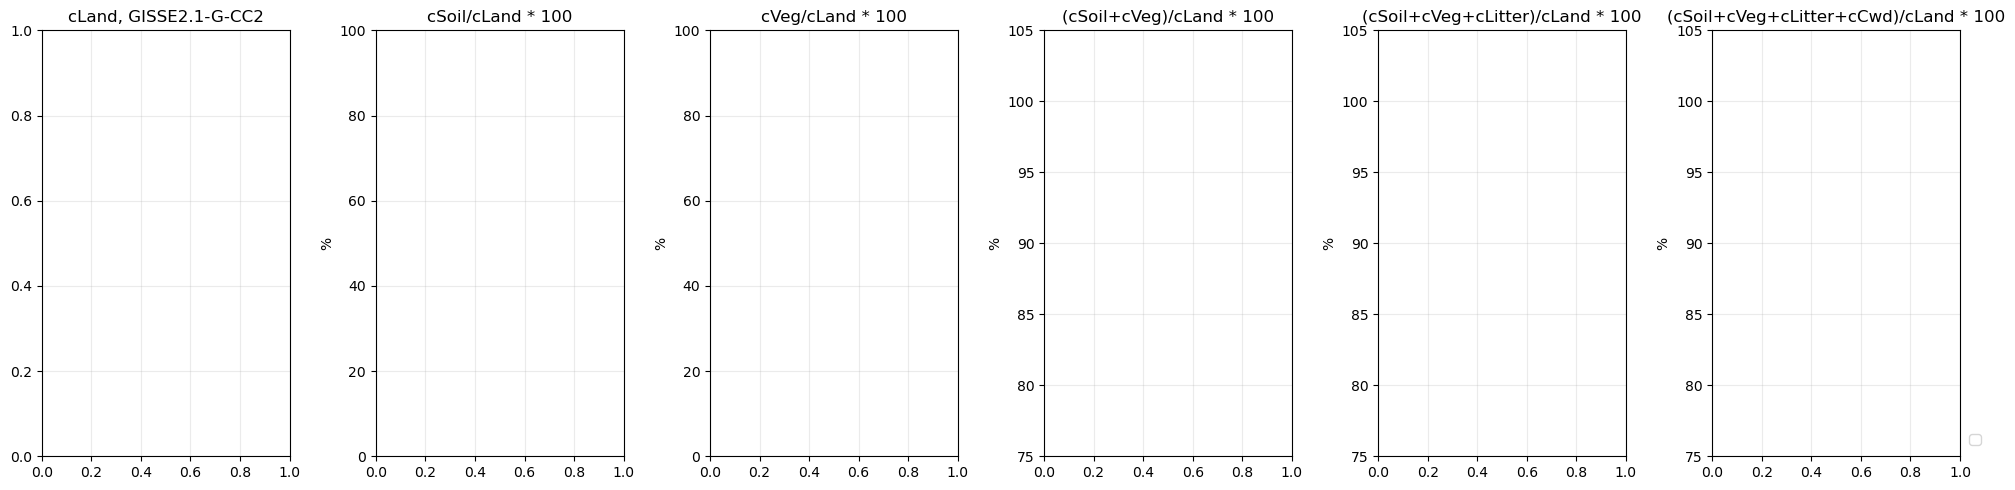

In [24]:
for model in models:
    fig, ax = plt.subplots(1, 6, figsize=(20, 5))

    for run in runs:
        try:
            color = run_dict[run].color_id

            cLand = global_stats[model]['cLand'][run]

            # --- base plot ---
            cLand.plot(alpha=0.25, color=color, ax=ax[0])
            cLand.resample(time="1YS").mean().plot(alpha=1, color=color, ax=ax[0], label=run)

            # --- core fractions ---
            soilfrac = global_stats[model].get('cSoil', {}).get(run, 0) / cLand * 100
            vegfrac  = global_stats[model].get('cVeg', {}).get(run, 0) / cLand * 100

            # optional pools (independent!)
            litterfrac = global_stats[model].get('cLitter', {}).get(run, 0)
            litterfrac = litterfrac / cLand * 100 if isinstance(litterfrac, type(cLand)) else 0
            
            Cwdfrac = global_stats[model].get('cCwd', {}).get(run, 0)
            Cwdfrac = Cwdfrac / cLand * 100 if isinstance(Cwdfrac, type(cLand)) else 0

            # --- plotting ---
            def plot_pair(data, axis):
                data.plot(alpha=0.25, color=color, ax=axis)
                data.resample(time="1YS").mean().plot(alpha=1, color=color, ax=axis)

            plot_pair(soilfrac, ax[1])
            plot_pair(vegfrac, ax[2])
            plot_pair(soilfrac + vegfrac, ax[3])
            plot_pair(soilfrac + vegfrac + litterfrac, ax[4])
            plot_pair(soilfrac + vegfrac + litterfrac + Cwdfrac, ax[5])

        except Exception as e:
            print(f"Skipping {model}, {run}: {e}")

    # --- formatting ---
    ax[0].set_title(f'cLand, {model}')
    ax[1].set_title('cSoil/cLand * 100')
    ax[2].set_title('cVeg/cLand * 100')
    ax[3].set_title('(cSoil+cVeg)/cLand * 100')
    ax[4].set_title('(cSoil+cVeg+cLitter)/cLand * 100')
    ax[5].set_title('(cSoil+cVeg+cLitter+cCwd)/cLand * 100')

    for axi in ax:
        axi.grid(alpha=0.25)

    for axi in ax[1:-2]:
        axi.set_ylim([0, 100])

    for axi in ax[-3:]:
        axi.set_ylim([75, 105])

    # y-labels
    for axi in ax[1:]:
        axi.set_ylabel('%')
    
    plt.subplots_adjust(right=0.8)
    plt.legend(loc='lower left', bbox_to_anchor=(1.01, 0.01))
    plt.tight_layout()
    plt.show()